# Notebook 1 — Synthetic Data & EDA

Generates 2 years of weekly marketing data across 4 channels and explores it before modelling.

In [ ]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from src.transforms import adstock, hill

np.random.seed(42)
sns.set_theme(style='whitegrid')
%matplotlib inline

os.makedirs('../data', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

## 1. Generate synthetic weekly data

In [ ]:
N_WEEKS = 104  # 2 years
dates = pd.date_range('2023-01-02', periods=N_WEEKS, freq='W-MON')

# Seasonality
t = np.arange(N_WEEKS)
seasonality = 1 + 0.15 * np.sin(2 * np.pi * t / 52) + 0.08 * np.sin(4 * np.pi * t / 52)

# Raw weekly spend per channel (£000s)
tv_spend      = np.random.gamma(shape=4, scale=50, size=N_WEEKS)
search_spend  = np.random.gamma(shape=8, scale=15, size=N_WEEKS)
social_spend  = np.random.gamma(shape=5, scale=20, size=N_WEEKS)
display_spend = np.random.gamma(shape=3, scale=10, size=N_WEEKS)

CHANNEL_PARAMS = {
    'tv':      dict(coef=3.0, decay=0.6, ec=150, slope=1.5),
    'search':  dict(coef=5.0, decay=0.2, ec=80,  slope=2.0),
    'social':  dict(coef=2.5, decay=0.4, ec=60,  slope=1.8),
    'display': dict(coef=1.5, decay=0.3, ec=30,  slope=1.5),
}
spends = [tv_spend, search_spend, social_spend, display_spend]
channel_contrib = sum(
    p['coef'] * hill(adstock(s, decay=p['decay']), ec=p['ec'], slope=p['slope'])
    for s, p in zip(spends, CHANNEL_PARAMS.values())
)

base_revenue = 500  # £000s
revenue = base_revenue * seasonality + channel_contrib + np.random.normal(0, 20, N_WEEKS)

spend_cols = ['tv_spend', 'search_spend', 'social_spend', 'display_spend']
colors     = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

df = pd.DataFrame({
    'date':         dates,
    'revenue':      revenue,
    'tv_spend':     tv_spend,
    'search_spend': search_spend,
    'social_spend': social_spend,
    'display_spend':display_spend,
})

df.to_csv('../data/synthetic_mmm.csv', index=False)
print(df.shape)
df.head()

## 2. Revenue over time

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['date'], df['revenue'], color='steelblue', linewidth=1.5)
ax.set_title('Weekly Revenue', fontsize=14)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
plt.tight_layout()
plt.savefig('../outputs/revenue_timeseries.png', dpi=150)
plt.show()

## 3. Media spend by channel

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
for ax, col, color in zip(axes, spend_cols, colors):
    ax.fill_between(df['date'], df[col], alpha=0.6, color=color)
    ax.plot(df['date'], df[col], color=color, linewidth=0.8)
    ax.set_ylabel(col.replace('_spend', '').title(), fontsize=10)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
fig.suptitle('Weekly Media Spend by Channel', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/spend_by_channel.png', dpi=150)
plt.show()

## 4. Spend share (pie)

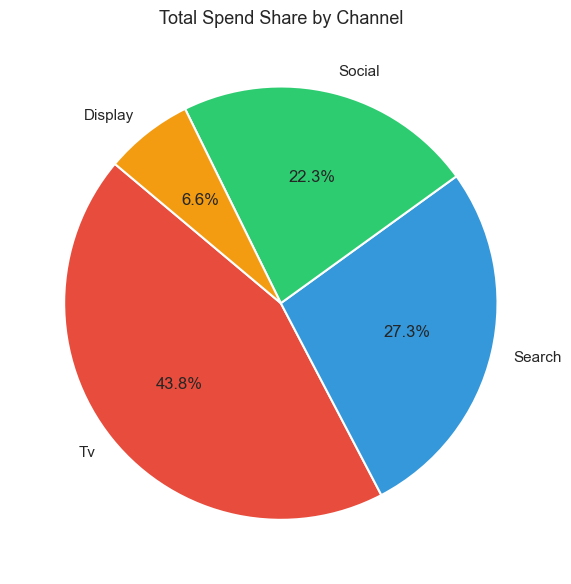

In [5]:
totals = df[spend_cols].sum()
labels = [c.replace('_spend','').title() for c in spend_cols]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(totals, labels=labels, autopct='%1.1f%%', colors=colors,
       startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Total Spend Share by Channel', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/spend_share_pie.png', dpi=150)
plt.show()

## 5. Correlation heatmap

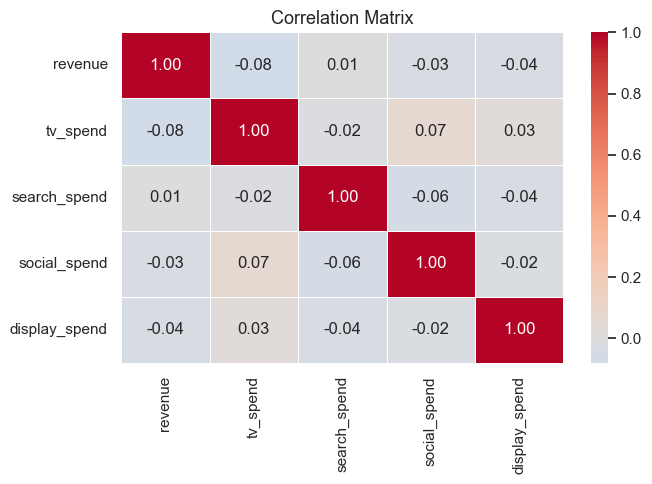

In [6]:
corr = df[['revenue'] + spend_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()

## 6. Summary stats

In [ ]:
from IPython.display import display

summary = df[['revenue'] + spend_cols].describe().T
summary['total'] = df[['revenue'] + spend_cols].sum()
display(summary.style.format('{:,.1f}'))